Dynamic susceptibility $\chi$, also known as AC-susceptibility, is defined as the response of the magnetization
of the sample to a small change in the magnetic field:
$$
\chi = \frac{d M}{d H}
$$

By applying an alternating magnetic field,
$$
H(t) = H_0 + h \cos(\omega t)
$$

The magnetization due to $H(t)$ is
$$
M(t) = M_0 + m \cos(\omega t - \phi)
$$
where $\phi$ is the phase angle which describes the delay of M(t) relative to H(t). One gets
$$
M(t) = M_0 + \chi' h \cos(\omega t) +  \chi'' h \sin(\omega t)
$$
where $\chi'=\frac{m}{h}\cos\phi$ and $\chi''=\frac{m}{h}\sin\phi$. We can compute $\chi$ using Fourier transformation,

$$
\chi(\omega) = \hat{m}(\omega)/ \hat{h}(\omega)
$$
where $\hat{m}(\omega)$ and $\hat{h}(\omega)$ are Fourier transform of $m(t)$ and $h(t)$.

In [1]:
using MicroMagnetic
using DelimitedFiles
using CairoMakie
using FFTW

Enable GPU acceleration

In [2]:
@using_gpu()

mesh = FDMesh(; nx=200, ny=50, nz=1, dx=2.5e-9, dy=2.5e-9, dz=3e-9);

## Step 1: Relaxing the System
The first step in our simulation is to relax the system to obtain a stable magnetization configuration, often referred to as an "S" state. We encapsulate this process in the `relax_system` function.

[ Info: MicroSim has been created.
[ Info: Exchange has been added.
[ Info: Running Driver : MicroMagnetic.EnergyMinimization{Float64}.
[ Info: max_dmdt is less than stopping_dmdt=0.001 @steps=415, Done!


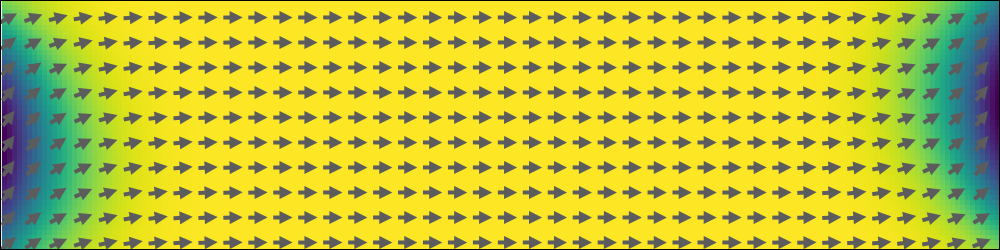

In [3]:
function relax_system(mesh)
   sim = Sim(mesh; driver="SD", name="std4_bar")

   Ms = 8e5
   A = 1.3e-11

   set_Ms(sim, Ms)   # Set saturation magnetization
   add_exch(sim, A)  # Add exchange interaction
   add_demag(sim)    # Add demagnetization

   init_m0(sim, (1, 0.25, 0.1))  # Initialize magnetization
   relax(sim; stopping_dmdt=0.001)  # Relax the system

   return sim
end

sim = relax_system(mesh);
plot_m(sim; component='x')

## Step 2: Applying external field

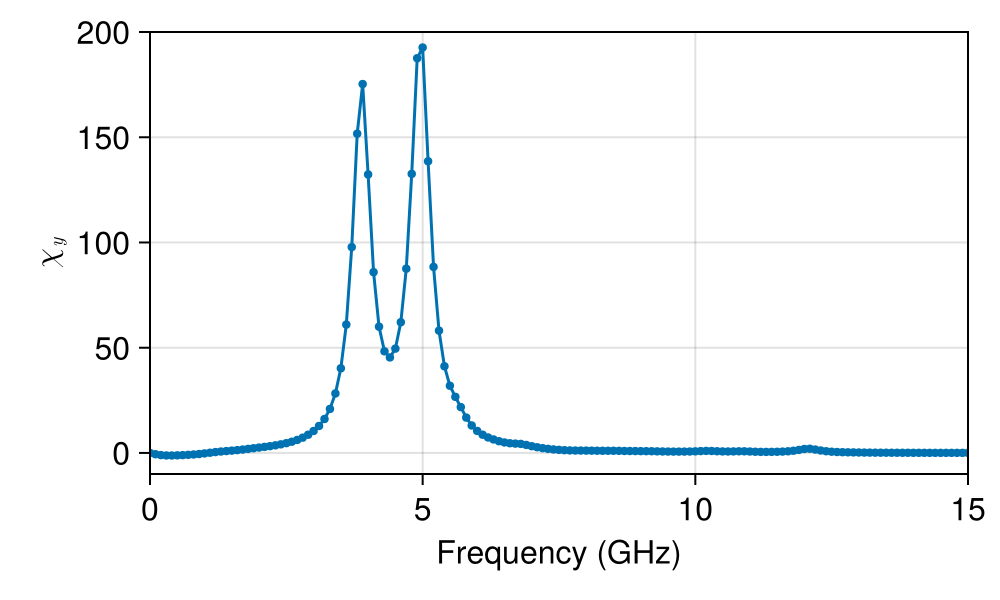

In [4]:
function time_fun(t)
    w = 2*pi*2.0e9
    return (0, sinc(w*t), 0)
end

function run_dynamics(sim)
    set_driver(sim; driver="LLG", alpha=0.015, gamma=2.211e5)
    sim.driver.tol = 1e-8
    add_zeeman(sim, (0, 500, 0), time_fun, name="zee")  # Apply external magnetic field in the y-direction

    run_sim(sim; steps=10000, dt=1e-12, save_m_every=-1)  # Run the simulation for 10000 steps
end

function compute_chi(Ms=8e5)
    data, units = read_table("std4_bar_llg.txt")

    time = data["time"]
    dt = time[2] - time[1]
    N = length(time)
    println(dt)

    freq = fftshift(fftfreq(N, 1/dt))

    M = data["m_y"]
    H = data["zee_Hy"]
    fH = fftshift(fft(H))
    fM = fftshift(fft(M .- M[1]))

    a = real(fH)
    b = imag(fH)
    c = real(fM)
    d = imag(fM)

    rx = (a .* c .+ b .* d) ./ (a .* a .+ b .* b)
    ix = (b .* c .- a .* d) ./ (a .* a .+ b .* b)

    return freq*1e-9, rx*Ms, ix*Ms
end

function plot_chi()

    data = readdlm("assets/chi.txt")

    freq = data[:, 1]
    ix = data[:, 3]

    fig = Figure(; size=(500, 300), fontsize=16)
    ax = Axis(fig[1, 1]; xlabel="Frequency (GHz)", ylabel=L"\chi_y")

    scatterlines!(ax, freq, ix; markersize=6)
    xlims!(ax, 0, 15)
    ylims!(ax, -10, 200)
    return fig
end

if !isfile("assets/chi.txt")

    run_dynamics(sim)

    freq, rx, ix = compute_chi()

    s = div(length(freq), 2)
    data = [freq[s:end] rx[s:end] ix[s:end]]
    writedlm("assets/chi.txt", data)
end

plot_chi()

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*